In [21]:
import pandas as pd
import cooler
import cooltools
from ggner_3d.boundaries import preserved_boundaries_only, make_tads, assign_domain_score
from ggner_3d.bbi_helpers import stackup_bw_dict
from ggner_3d.cm import prepare_view_df
import bioframe as bf
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

from ggner_3d import plotting
plotting.update_rcparams()
COLORS = plotting.COLORS

import warnings
# ignore FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)

label_expected = 'chrom'
resolution = 10_000
window = 500_000

# tad lengths
MAXLEN = 2e6
MINLEN = 2.5e5

rescale_flank = 1
rescale_size = 33 * (2 * rescale_flank + 1)
assert rescale_size % (2 * rescale_flank + 1) == 0 and rescale_size % 2 == 1, "rescale_size"
score_flank=rescale_flank

In [22]:
rna_bw_dict = {
    't0': ['/home/carlos/oldies/manuscripts/notebooks/viz/merged_t00.bw'],
    't12': ['/home/carlos/oldies/manuscripts/notebooks/viz/merged_t12.bw'],
    't30': ['/home/carlos/oldies/manuscripts/notebooks/viz/merged_t30.bw'],
    't60': ['/home/carlos/oldies/manuscripts/notebooks/viz/merged_t60.bw']
}

pol2_dict = {
    'hela_nouv_pol2': ['/home/carlos/Downloads/ENCFF144IVU.bigWig']
}

In [23]:
clr_t0 = cooler.Cooler(f"/home/carlos/Clone/ggner-3d/data/hela/GSM8289939_t0_q30.mcool::/resolutions/{resolution}")
clr_t12 = cooler.Cooler(f"/home/carlos/Clone/ggner-3d/data/hela/GSM8289940_t12_q30.mcool::/resolutions/{resolution}")
clr_t30 = cooler.Cooler(f"/home/carlos/Clone/ggner-3d/data/hela/GSM8289941_t30_q30.mcool::/resolutions/{resolution}")
clr_t60 = cooler.Cooler(f"/home/carlos/Clone/ggner-3d/data/hela/GSM8289942_t60_q30.mcool::/resolutions/{resolution}")

In [24]:
samples = ['t0', 't12', 't30', 't60']

In [25]:
# insulation_dfs = [cooltools.insulation(
#             clr = clr,
#             window_bp = [window],
#             clr_weight_name='weight',
#             nproc=6
#         ) for clr in [clr_t0, clr_t12, clr_t30, clr_t60]]

# for i, ins_df in enumerate(insulation_dfs):
#     ins_df.to_csv(f'/home/carlos/Clone/ggner-3d/data/hela/insulation_{window}_{samples[i]}.tsv', sep='\t', index=False)

insulation_dfs = [pd.read_csv(f'/home/carlos/Clone/ggner-3d/data/hela/insulation_{window}_{sample}.tsv', sep='\t') for sample in samples]

In [26]:
def chrom_to_bin_indices(df, bins_table, bin_column = 'idx1'):
    df = df.copy()
    bins_table['indices'] = bins_table.index
    return pd.merge(df, bins_table, left_on=bin_column, right_on='indices')

comparisons = [(0,1), (1,2), (2,3)]
comparisons_str = ['t0_t12', 't12_t30', 't30_t60']
sample_names_str = ['t0', 't12', 't30', 't60']
accepted_range = 1

results, dfs = preserved_boundaries_only(
    comparisons=comparisons,
    comparisons_str=comparisons_str,
    sample_names_str=sample_names_str,
    accepted_range=accepted_range,
    insulation_table_=insulation_dfs,
    window=window,
)

dfs = [
    chrom_to_bin_indices(df, clr_t0.bins()[:], bin_column='idx1') for df in dfs
]

t0_t12: Preserved / Increase ::: 2414
t0_t12: Preserved / Decrease ::: 457
t12_t30: Preserved / Increase ::: 1170
t12_t30: Preserved / Decrease ::: 1826
t30_t60: Preserved / Increase ::: 1715
t30_t60: Preserved / Decrease ::: 1333


In [27]:
s1 = 't0'
s2 = 't12'
s1_index = sample_names_str.index(s1)
s2_index = sample_names_str.index(s2)
comp_name = 't0_t12'
comp_index = comparisons_str.index(comp_name)

def map_idx_to_bs(ins_df, common_df, on_col1=f'boundary_strength_{window}', on_col2='idx1'):
    ins_df = ins_df.copy()
    common_df = common_df.copy()
    common_df['bs'] = ins_df[on_col1].iloc[common_df[on_col2].values].values
    return common_df

common_boundaries = dfs[comp_index].copy()
common_boundaries[f'bs_s{s1}'] = map_idx_to_bs(insulation_dfs[s1_index], dfs[comp_index], on_col2='idx1')['bs']
common_boundaries[f'bs_s{s2}'] = map_idx_to_bs(insulation_dfs[s2_index], dfs[comp_index], on_col2='idx2')['bs']

In [28]:
# common_boundaries['bs_change'] = common_boundaries[f'bs_s{s2}'] - common_boundaries[f'bs_s{s1}']
common_boundaries['bs_change'] = common_boundaries[f'bs_s{s2}'] - common_boundaries[f'bs_s{s1}']
common_boundaries['Q'] = pd.qcut(common_boundaries['bs_change'], q=4, labels=False) + 1

In [29]:
common_tads = make_tads(common_boundaries[['chrom', 'start', 'end']].copy(), maxlen=MAXLEN, minlen=MINLEN)
common_tads.shape

(2398, 3)

In [30]:
if label_expected == 'chrom':
    view_df = prepare_view_df(arm=False)
else:
    view_df = prepare_view_df(arm=True)

In [31]:


# t0_expected = cooltools.expected_cis(
#             clr=clr_t0,
#             nproc=6,
#             view_df = view_df,
#             clr_weight_name='weight',
#         )

# t12_expected = cooltools.expected_cis(
#             clr=clr_t12,
#             nproc=6,
#             view_df = view_df,
#             clr_weight_name='weight',
#         )

# t30_expected = cooltools.expected_cis(
#             clr=clr_t30,
#             nproc=6,
#             view_df = view_df,
#             clr_weight_name='weight',
#         )

# t60_expected = cooltools.expected_cis(
#             clr=clr_t60,
#             nproc=6,
#             view_df = view_df,
#             clr_weight_name='weight',
#         )


# for i, exp_df in enumerate([t0_expected, t12_expected, t30_expected, t60_expected]):
#     exp_df.to_csv(f'/home/carlos/Clone/ggner-3d/data/hela/expected_{label_expected}_{samples[i]}.tsv', sep='\t', index=False)

In [32]:
t0_expected = pd.read_csv(f'/home/carlos/Clone/ggner-3d/data/hela/expected_{label_expected}_t0.tsv', sep='\t')
t12_expected = pd.read_csv(f'/home/carlos/Clone/ggner-3d/data/hela/expected_{label_expected}_t12.tsv', sep='\t')
t30_expected = pd.read_csv(f'/home/carlos/Clone/ggner-3d/data/hela/expected_{label_expected}_t30.tsv', sep='\t')
t60_expected = pd.read_csv(f'/home/carlos/Clone/ggner-3d/data/hela/expected_{label_expected}_t60.tsv', sep='\t')

In [33]:
t0_tads_str = assign_domain_score(
    tads_df=common_tads,
    clr=clr_t0,
    expected=t0_expected,
    view_df=view_df,
    resolution=resolution,
    nproc=8,
    clr_weight_name='weight',
    rescale_flank=rescale_flank,
    score_flank=score_flank,
    rescale_size=rescale_size
)

t12_tads_str = assign_domain_score(
    tads_df=common_tads,
    clr=clr_t12,
    expected=t12_expected,
    view_df=view_df,
    resolution=resolution,
    nproc=8,
    clr_weight_name='weight',
    rescale_flank=rescale_flank,
    score_flank=score_flank,
    rescale_size=rescale_size
)

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr4', 'chr4'): 129
INFO:coolpuppy:('chr8', 'chr8'): 118
INFO:coolpuppy:('chr3', 'chr3'): 156
INFO:coolpuppy:('chr7', 'chr7'): 137
INFO:coolpuppy:('chr6', 'chr6'): 155
INFO:coolpuppy:('chr5', 'chr5'): 143
INFO:coolpuppy:('chr1', 'chr1'): 211
INFO:coolpuppy:('chr2', 'chr2'): 180
INFO:coolpuppy:('chr9', 'chr9'): 111
INFO:coolpuppy:('chr10', 'chr10'): 106
INFO:coolpuppy:('chr14', 'chr14'): 72
INFO:coolpuppy:('chr15', 'chr15'): 81
INFO:coolpuppy:('chr13', 'chr13'): 68
INFO:coolpuppy:('chr16', 'chr16'): 59
INFO:coolpuppy:('chr11', 'chr11'): 120
INFO:coolpuppy:('chr12', 'chr12'): 130
INFO:coolpuppy:('chr21', 'chr21'): 24
INFO:coolpuppy:('chr17', 'chr17'): 93
INFO:coolpuppy:('chr18', 'chr18'): 59
INFO:coolpuppy:('chr19', 'chr19'): 62
INFO:coolpuppy:('chr22', 'chr22'): 32
INFO:coolpuppy:('chr20', 'chr20'): 64
INFO:coolpuppy:('chrX', 'chrX'): 77
INFO:coolpuppy:Total number of piled up windows: 211
INFO:coolpuppy:Re

In [34]:
t0 = t0_tads_str.rename(columns={'domain_score': 't0_ds'})
t12 = t12_tads_str.rename(columns={'domain_score': 't12_ds'})

tads_df = t0.merge(t12[['chrom','start','end','t12_ds']], on=['chrom','start','end'], how='inner')

tads_df['ds_diff_12'] = tads_df['t12_ds'] - tads_df['t0_ds']
tads_df['ds_Q_0_12'] = pd.qcut(tads_df['ds_diff_12'], q=4, labels=False) + 1

### rnaseq at tads

In [35]:
nbins = rescale_size

In [36]:
bin_table = clr_t0.bins()[:]

In [37]:
# import bbi
# rna_means = {}
# for k,v in rna_bw_dict.items():
#     bw = v[0]
#     stack = bbi.stackup(
#         bw,
#         bin_table['chrom'].values,
#         bin_table['start'].values,
#         bin_table['end'].values,
#         bins=1
#     )
#     rna_means[k] = np.nanmean(stack)

In [38]:
from coolpuppy import coolpup
pups_dict ={}
for q in sorted(tads_df['ds_Q_0_12'].unique()):
    current_df = tads_df[tads_df['ds_Q_0_12'] == q].copy()
    cc = coolpup.CoordCreator(current_df, resolution=10000, features_format='bed', local=True, rescale_flank=rescale_flank)
    pup_t0 = coolpup.PileUpper(clr_t0, cc, expected=t0_expected, view_df=view_df, ignore_diags=0, rescale_size=rescale_size, rescale=True, nproc = 8).pileupsWithControl()
    pup_t12 = coolpup.PileUpper(clr_t12, cc, expected=t12_expected, view_df=view_df, ignore_diags=0, rescale_size=rescale_size, rescale=True, nproc = 8).pileupsWithControl()
    pups_dict[int(q)] = (pup_t0, pup_t12)

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr1', 'chr1'): 47
INFO:coolpuppy:('chr2', 'chr2'): 42
INFO:coolpuppy:('chr4', 'chr4'): 35
INFO:coolpuppy:('chr6', 'chr6'): 34
INFO:coolpuppy:('chr3', 'chr3'): 44
INFO:coolpuppy:('chr8', 'chr8'): 29
INFO:coolpuppy:('chr5', 'chr5'): 29
INFO:coolpuppy:('chr7', 'chr7'): 31
INFO:coolpuppy:('chr9', 'chr9'): 20
INFO:coolpuppy:('chr13', 'chr13'): 16
INFO:coolpuppy:('chr14', 'chr14'): 21
INFO:coolpuppy:('chr10', 'chr10'): 29
INFO:coolpuppy:('chr11', 'chr11'): 32
INFO:coolpuppy:('chr12', 'chr12'): 31
INFO:coolpuppy:('chr15', 'chr15'): 22
INFO:coolpuppy:('chr16', 'chr16'): 17
INFO:coolpuppy:('chr18', 'chr18'): 16
INFO:coolpuppy:('chr19', 'chr19'): 17
INFO:coolpuppy:('chr21', 'chr21'): 12
INFO:coolpuppy:('chr17', 'chr17'): 26
INFO:coolpuppy:('chr22', 'chr22'): 11
INFO:coolpuppy:('chr20', 'chr20'): 11
INFO:coolpuppy:('chrX', 'chrX'): 25
INFO:coolpuppy:Total number of piled up windows: 597
INFO:coolpuppy:Rescaling with

In [39]:
tads_df['length'] = tads_df['end'] - tads_df['start']

tads_df['flank_start'] = tads_df['start'] - (tads_df['length'] * rescale_flank).astype(int)
tads_df['flank_end'] = tads_df['end'] + (tads_df['length'] * rescale_flank).astype(int)

tad_stacks_rna = {}
tad_stack_pol2 = {}
for q in sorted(tads_df['ds_Q_0_12'].unique()):
    tad_stacks_rna[int(q)] = stackup_bw_dict(
        bw_dict=rna_bw_dict,
        df=tads_df[tads_df['ds_Q_0_12'] == q],
        nbins=nbins
    )
    tad_stack_pol2[int(q)] = stackup_bw_dict(
        bw_dict=pol2_dict,
        df=tads_df[tads_df['ds_Q_0_12'] == q],
        nbins=nbins
    )

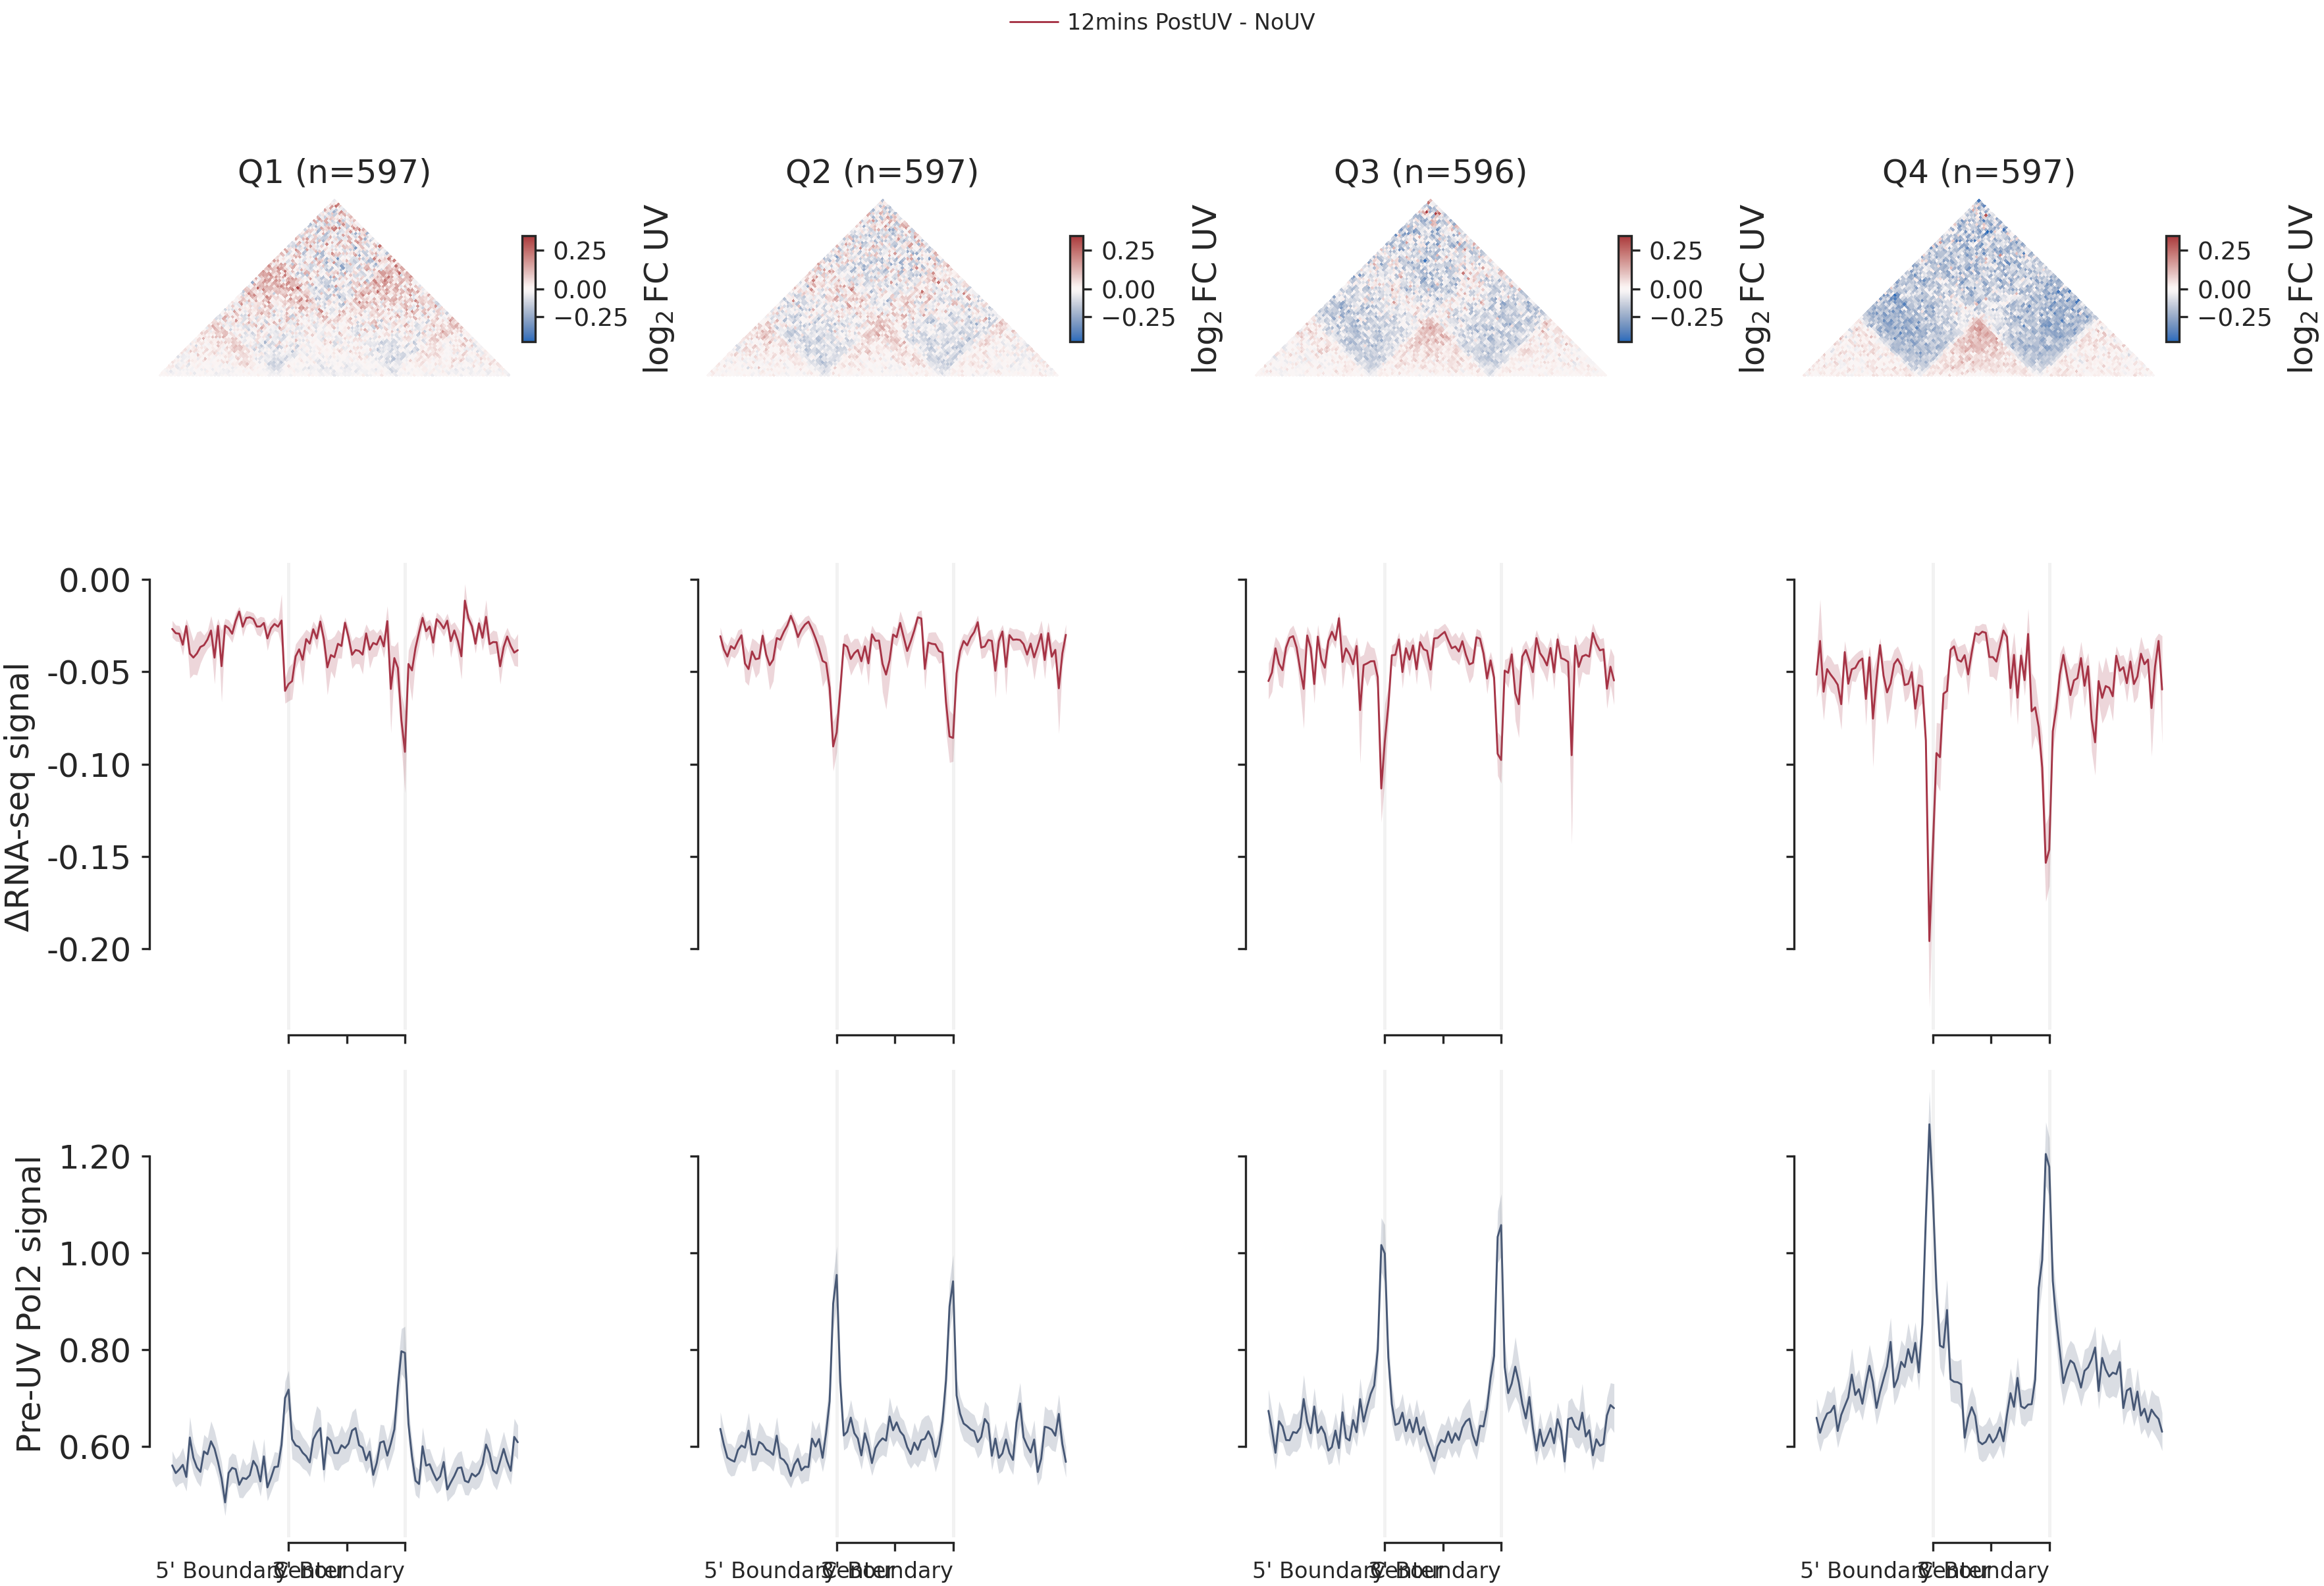

In [40]:
import numpy as np
import matplotlib.pyplot as plt

from ggner_3d.plotting import hic_upper_triangle
from ggner_3d.plotting import COLORS
from ggner_3d import plotting

# =========================================================
# CONFIG
# =========================================================
BAND_MODE = "mean_sem"          # options: "mean_sem", "median_iqr", "median_pct"
PCT_BAND = (10, 90)            # used only when BAND_MODE == "median_pct"
SHADE_ALPHA = 0.20
LINEWIDTH = 0.7
EPS = 1e-6

STANDARDIZE_MODE = "none"
# options:
#   "none"
#   "zscore_before_delta"
#   "zscore_after_delta"
#   "robust_zscore_before_delta"
#   "robust_zscore_after_delta"

# RNA_LINES_TO_PLOT = ["t12", "t30", "t60"]
RNA_LINES_TO_PLOT = ["t12"]

RNA_LINE_CONFIG = {
    "t12": {
        "time_key": "t12",
        "color": COLORS[1],
        "label": "12mins PostUV - NoUV",
    },
    "t30": {
        "time_key": "t30",
        "color": COLORS[2],
        "label": "30mins PostUV - NoUV",
    },
    "t60": {
        "time_key": "t60",
        "color": COLORS[3],
        "label": "60mins PostUV - NoUV",
    },
}

# =========================================================
# HELPERS
# =========================================================
def nansem(x, axis=0):
    """
    Standard error of the mean ignoring NaNs.
    x shape: (n_samples, n_bins)
    """
    n = np.sum(~np.isnan(x), axis=axis)
    sd = np.nanstd(x, axis=axis, ddof=1)
    sem = sd / np.sqrt(n)
    sem = np.where(n > 1, sem, np.nan)
    return sem


def summarize_with_band(x, mode="mean_sem", pct_band=(10, 90), axis=0):
    """
    Returns center, lower, upper for a curve + uncertainty band.

    mode:
      - "mean_sem"   : center = mean,    band = mean ± SEM
      - "median_iqr" : center = median,  band = 25th to 75th percentile
      - "median_pct" : center = median,  band = pct_band[0] to pct_band[1]
    """
    x = np.asarray(x)

    if mode == "mean_sem":
        center = np.nanmean(x, axis=axis)
        sem = nansem(x, axis=axis)
        lower = center - sem
        upper = center + sem
        label_suffix = "mean ± SEM"

    elif mode == "median_iqr":
        center = np.nanmedian(x, axis=axis)
        lower = np.nanpercentile(x, 25, axis=axis)
        upper = np.nanpercentile(x, 75, axis=axis)
        label_suffix = "median + IQR"

    elif mode == "median_pct":
        lo, hi = pct_band
        center = np.nanmedian(x, axis=axis)
        lower = np.nanpercentile(x, lo, axis=axis)
        upper = np.nanpercentile(x, hi, axis=axis)
        label_suffix = f"median + P{lo}-P{hi}"

    else:
        raise ValueError(
            "mode must be one of: 'mean_sem', 'median_iqr', 'median_pct'"
        )

    return center, lower, upper, label_suffix


def plot_curve_with_band(ax, y_stack, color, label, mode="mean_sem",
                         pct_band=(10, 90), linewidth=0.7, alpha=0.20):
    """
    y_stack shape: (n_samples, n_bins)
    """
    center, lower, upper, _ = summarize_with_band(
        y_stack, mode=mode, pct_band=pct_band, axis=0
    )
    x = np.arange(y_stack.shape[1])

    ax.plot(x, center, color=color, linewidth=linewidth, label=label)
    ax.fill_between(x, lower, upper, color=color, alpha=alpha, linewidth=0)


def zscore(x, axis=1, eps=1e-8):
    mu = np.nanmean(x, axis=axis, keepdims=True)
    sd = np.nanstd(x, axis=axis, keepdims=True)
    return (x - mu) / (sd + eps)


def robust_zscore(x, axis=1, eps=1e-8):
    med = np.nanmedian(x, axis=axis, keepdims=True)
    mad = np.nanmedian(np.abs(x - med), axis=axis, keepdims=True)
    return (x - med) / (1.4826 * mad + eps)


def compute_delta(a, b, mode="none"):
    """
    a, b: arrays of shape (n_samples, n_bins)
    returns delta of shape (n_samples, n_bins)
    """
    if mode == "none":
        return b - a

    elif mode == "zscore_before_delta":
        a_std = zscore(a, axis=1)
        b_std = zscore(b, axis=1)
        return b_std - a_std

    elif mode == "zscore_after_delta":
        delta = b - a
        return zscore(delta, axis=1)

    elif mode == "robust_zscore_before_delta":
        a_std = robust_zscore(a, axis=1)
        b_std = robust_zscore(b, axis=1)
        return b_std - a_std

    elif mode == "robust_zscore_after_delta":
        delta = b - a
        return robust_zscore(delta, axis=1)

    else:
        raise ValueError(f"Unknown STANDARDIZE_MODE: {mode}")


def validate_rna_lines(rna_lines_to_plot, rna_line_config):
    invalid = [x for x in rna_lines_to_plot if x not in rna_line_config]
    if invalid:
        raise ValueError(
            f"Invalid RNA_LINES_TO_PLOT entries: {invalid}. "
            f"Valid options are: {list(rna_line_config.keys())}"
        )


# =========================================================
# FIGURE SETUP
# =========================================================
validate_rna_lines(RNA_LINES_TO_PLOT, RNA_LINE_CONFIG)

fig, ax = plt.subplots(3, 4, figsize=(12, 8), sharey='row')
plotting.update_rcparams()

unit_size = rescale_size // (2 * rescale_flank + 1)
fiveprime_bin = unit_size * rescale_flank
threeprime_bin = unit_size * (rescale_flank + 1)
tad_center_bin = (fiveprime_bin + threeprime_bin) / 2

quartiles = sorted(tads_df['ds_Q_0_12'].unique())

# =========================================================
# TOP ROW: Hi-C delta heatmaps
# =========================================================
mats = []
for q in quartiles:
    pup_t0, pup_t12 = pups_dict[q]
    divide_pup = np.log2(pup_t12['data'][0] + EPS) - np.log2(pup_t0['data'][0] + EPS)
    mats.append(divide_pup)

stacked_mats = np.stack(mats)
vmin, vmax = np.nanmin(stacked_mats), np.nanmax(stacked_mats)
# vmin, vmax = np.nanpercentile(stacked_mats, 1), np.nanpercentile(stacked_mats, 99)

for i, q in enumerate(quartiles):
    pup_t0, pup_t12 = pups_dict[q]
    divide_pup = np.log2(pup_t12['data'][0] + EPS) - np.log2(pup_t0['data'][0] + EPS)

    h_ax = hic_upper_triangle(
        divide_pup,
        ax=ax[0, i],
        cmap='vlag',
        center=0,
        vmin=vmin,
        vmax=vmax,
        colorbar=True,
        cbar_kws=dict(fraction=0.035, pad=0.02, aspect=8)
    )

    cbar = h_ax.figure.axes[-1]
    cbar.set_ylabel(r"$\log_{2}$FC UV", labelpad=5)

    for artist in ax[0, i].images + ax[0, i].collections:
            artist.set_rasterized(True)

    n_q = len(tads_df[tads_df['ds_Q_0_12'] == q])
    ax[0, i].set_title(f"Q{q} (n={n_q})")


# =========================================================
# MIDDLE ROW: RNA deltas with selectable lines
# =========================================================
for k, v in tad_stacks_rna.items():
    a = ax[1, k - 1]

    for line_key in RNA_LINES_TO_PLOT:
        cfg = RNA_LINE_CONFIG[line_key]
        delta = compute_delta(v['t0'], v[cfg["time_key"]], mode=STANDARDIZE_MODE)

        plot_curve_with_band(
            a,
            delta,
            color=cfg["color"],
            label=cfg["label"],
            mode=BAND_MODE,
            pct_band=PCT_BAND,
            linewidth=LINEWIDTH,
            alpha=SHADE_ALPHA
        )

    # a.axhline(0, color='grey', linestyle='--', alpha=0.5)


# =========================================================
# BOTTOM ROW: Pol2 with same switchable summary/band
# =========================================================
for k, v in tad_stack_pol2.items():
    pol2 = v['hela_nouv_pol2']

    if STANDARDIZE_MODE == "zscore_after_delta":
        pol2_plot = zscore(pol2, axis=1)
    elif STANDARDIZE_MODE == "robust_zscore_after_delta":
        pol2_plot = robust_zscore(pol2, axis=1)
    else:
        pol2_plot = pol2

    a = ax[2, k - 1]
    plot_curve_with_band(
        a, pol2_plot,
        color=COLORS[0],
        label=f"Q{k} Pol2",
        mode=BAND_MODE,
        pct_band=PCT_BAND,
        linewidth=LINEWIDTH,
        alpha=SHADE_ALPHA
    )
    
# =========================================================
# STYLING
# =========================================================
custom_xticks = [fiveprime_bin, tad_center_bin, threeprime_bin]
custom_xticklabels = ["5' Boundary", "Center", "3' Boundary"]

# RNA row
for a in ax[1, :]:
    a.axvline(fiveprime_bin, color='grey', alpha=0.1)
    a.axvline(threeprime_bin, color='grey', alpha=0.1)
    a.set_xticks(custom_xticks)
    a.set_xticklabels([])  # keep RNA-row x tick labels hidden
    plotting.despine(ax=a)

    a.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

# Pol2 row
for a in ax[2, :]:
    a.axvline(fiveprime_bin, color='grey', alpha=0.1)
    a.axvline(threeprime_bin, color='grey', alpha=0.1)
    a.set_xticks(custom_xticks)
    a.set_xticklabels(custom_xticklabels)
    plotting.despine(ax=a)

    a.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

ax[1, 0].set_ylabel("ΔRNA-seq signal")
ax[2, 0].set_ylabel("Pre-UV Pol2 signal")

handles, labels = ax[1, 0].get_legend_handles_labels()
if handles:
    fig.legend(
        handles, labels,
        loc="upper center",
        ncol=max(1, len(labels)),
        frameon=False,
        bbox_to_anchor=(0.5, 1.02)
    )

for a in ax.flatten():
    plotting.despine(ax=a)
    a.set_ylabel(a.get_ylabel(), fontsize=12)
    a.set_xlabel(a.get_xlabel(), fontsize=12)
    a.tick_params(axis='both', which='major', labelsize=12)

# Apply x tick label rotation/alignment LAST
for a in ax[2, :]:
    plt.setp(
        a.get_xticklabels(),
        rotation=0,
        ha="right",
        rotation_mode="anchor",
        fontsize=8
    )


fig.tight_layout()
fig.savefig('/home/carlos/Clone/ggner-3d/figs/hela/hela_tads_stratified_by_isolation_change_preUV_vs_12mins_PostUV_difference.png', dpi=300, bbox_inches='tight')
fig.savefig('/home/carlos/Clone/ggner-3d/figs/hela/hela_tads_stratified_by_isolation_change_preUV_vs_12mins_PostUV_difference.svg', dpi=300, bbox_inches='tight')
plt.show()